In [1]:
ROOT = '/kaggle/input/datasets/suryaraji2013/201-company-logos/'

We're going to make a little EDA plot based in ResNeXt image embeddings, so let's add some code to get those for us.

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 137MB/s]


Let's load up all of our data. We have separate folders for training and test splits, but no good way to build a model, so we're going to tag every image the same.

In [3]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image

THUMBNAIL_SIZE = (64, 64)

def embed(model, filename: str):
    try:
        with Image.open(fp=filename, mode='r') as image:
            return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)
    except: 
        print(filename)
        return None


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        # our images are pretty big; let's shrink the hover images to thumbnail size
        image.resize(size=THUMBNAIL_SIZE).convert('RGB').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'])
        for index, input_file in enumerate(tqdm.tqdm(desc='images', iterable=list(iglob(pathname=arg)))) if input_file.endswith('.jpg') or input_file.endswith('.png')]
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*.*' for folder in iglob(ROOT + '/*') if isdir(folder)}
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for (key, value) in train_dict.items()]))
train_df['tag'] = 'logo'
print('done in {}'.format(arrow.now() - time_start))

images:   2%|▏         | 3/181 [00:00<00:48,  3.70it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
images: 100%|██████████| 20/20 [00:03<00:00,  5.85it/s]

done in 0:00:37.911423


Let's add the x/y coordinates based on the image embeddings, using TSNE.

In [4]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 201 samples in 0.002s...
[t-SNE] Computed neighbors for 201 samples in 0.059s...
[t-SNE] Computed conditional probabilities for sample 201 / 201
[t-SNE] Mean sigma: 5.375410
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.637314
[t-SNE] KL divergence after 1000 iterations: 0.866049


Let's plot. We don't have a lot of data, so we're going to plot all of the images in a single static plot.

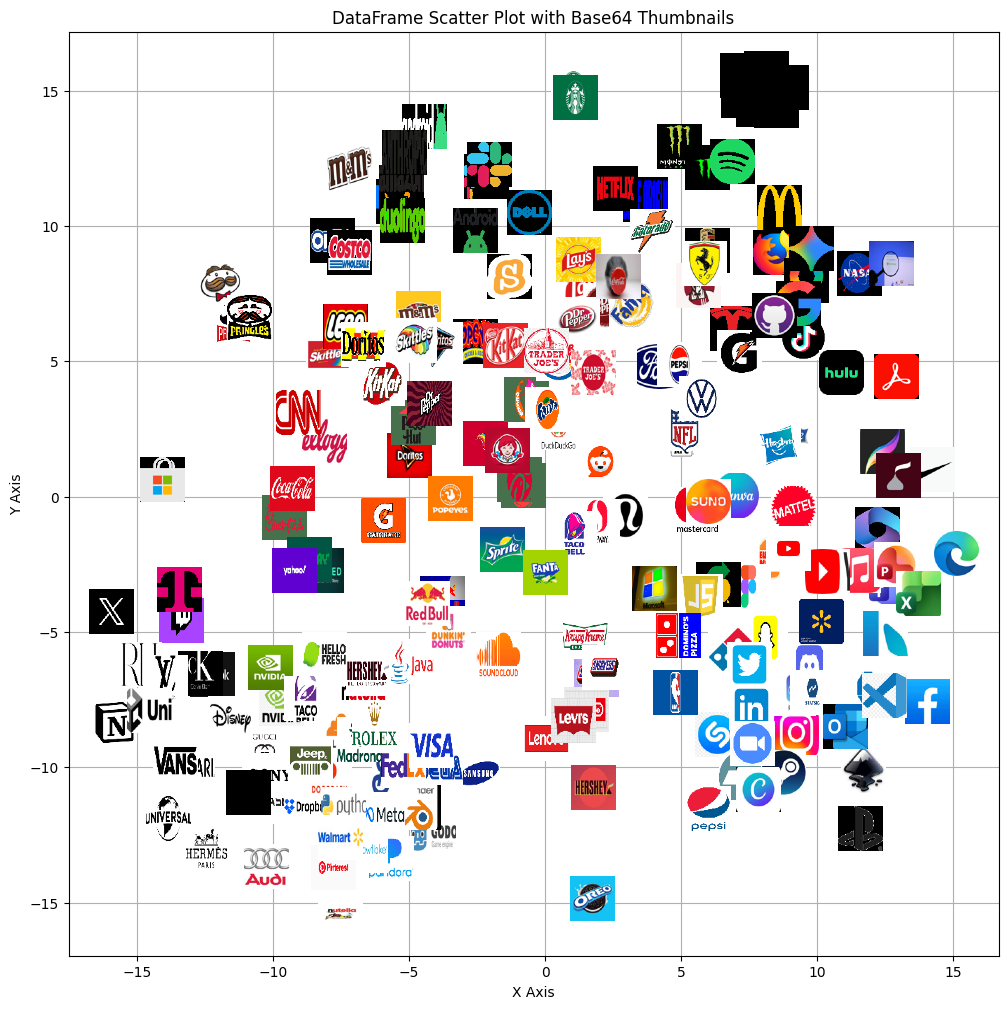

In [5]:
import base64
import io
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from PIL import Image



train_df['PNG'] = train_df['png'].str.replace('^data:image/png;base64,', '', regex=True)

# 1. Setup the plot structure
fig, ax = plt.subplots(figsize=(12, 12))

# 2. Iterate directly over the DataFrame rows
for index, row in train_df.iterrows():
    # Decode the base64 string back into raw image bytes
    img_bytes = base64.b64decode(row["PNG"])

    # Load the bytes into an image object using PIL
    img = Image.open(io.BytesIO(img_bytes))

    # Convert the image to a drawable object (adjust zoom to scale thumbnails)
    imagebox = OffsetImage(img, zoom=0.5)

    # Place the thumbnail at the row's specific (x, y) coordinates
    ab = AnnotationBbox(imagebox, (row["x"], row["y"]), frameon=False, pad=0)

    # Render the thumbnail onto the axis
    ax.add_artist(ab)

# 3. Plot invisible points using the columns to auto-scale the axes
ax.scatter(train_df["x"], train_df["y"], alpha=0)

plt.title("DataFrame Scatter Plot with Base64 Thumbnails")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.grid(True)
plt.show()
